In [ ]:
# (SmartAI Senior Guardian

# Statement of the Problem
# Out of 54 million, approximately 14 million older adults in the United States live alone, with many managing multiple chronic conditions — including high blood pressure,
# diabetes, and fall risk — without consistent support or monitoring. In the Washington DC–Maryland–Virginia (DMV) region, this challenge is acute.
# Consider a 74-year-old woman in Silver Spring, Maryland, living independently: she struggles to track her blood pressure readings, misses warning signs of glucose
 # fluctuation, and has no one nearby to respond if she falls. Without timely intervention, such situations become medical emergencies.
# The financial toll is equally alarming. Fall-related injuries alone cost the U.S. healthcare system over $50 billion annually,
# with older adults accounting for the vast majority of those costs. Preventable hospitalizations driven by unmanaged hypertension and
# diabetes add tens of billions more each year — burdens borne by Medicare, Medicaid, families, and seniors themselves. Yet much of this spending is
# reactive, treating crises that earlier monitoring could have prevented.
# SmartAI Senior Guardian addresses this critical gap through AI-powered, real-time health monitoring for at-risk seniors aging in place — reducing both human
# suffering and the staggering financial cost of preventable emergencies.

# Architecture

# SmartGuardian Device (Watch + CGM Patch)
            #  ↓
     # Real-time Data Stream
          #    ↓
    # ┌─────────────────────┐
    # │  # SUPERVISOR AGENT   │  ← Orchestrates all 4 agents
    #└─────────────────────┘
       #  ↙   ↓   ↘   ↘

# 1️⃣ HEALTH AGENT      2️⃣ FALL AGENT
  # Detects risk          Checks mobility
   # - BP readings         - Accelerometer data
   # - Glucose levels      - Weather conditions
   # - Heart rate          - Gait patterns
   # - SpO2                - Risk scoring
       # ↘                    ↙
         # 3️⃣ ALERT AGENT
           #  Notifies
           # - Caregiver SMS/push
           # - Emergency services
           #- Patient nudge
              #  ↓
         #v4️⃣ REPORT AGENT
           # Summarizes
            #- Daily health digest
            #- Trend analysis
            #- CDC benchmark comparison
               # ↓
         # React Dashboard )

In [ ]:
# ── Install Kaggle CLI ─────────────────────────────────────
!pip install kaggle

print("✅ Kaggle installed!")

✅ Kaggle installed!


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"antenehkhabte","key":"9bc87966cd80450a295494066ba331da"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                                 title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
amar5693/screen-time-sleep-and-stress-analysis-dataset              Screen Time, Sleep & Stress Analysis Dataset           787136  2026-02-13 06:56:18.757000          11479        230  1.0              
amar5693/student-performance-dataset                                Student Performance Dataset                            177286  2026-02-12 06:04:44.613000           9851        156  1.0              
shree0910/online-vs-in-store-shopping-behaviour-dataset             Online vs In-Store Shopping Behaviour Dataset          354896  2026-02-18 08:16:20.137000           1098         29  1.0

In [ ]:
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip pima-indians-diabetes-database.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 31.2MB/s]
Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [ ]:
import pandas as pd

data = pd.read_csv("diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
data = data.drop(columns=["Pregnancies"], errors="ignore")
data.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [ ]:
data.shape

(768, 8)

In [ ]:
data[data["Age"] >= 60].shape

(32, 8)

In [ ]:
data.isnull().sum()

,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
simple_data = data[["Glucose", "BloodPressure", "Outcome"]]
simple_data.head()

,Glucose,BloodPressure,Outcome
0,148,72,1
1,85,66,0
2,183,64,1
3,89,66,0
4,137,40,1


In [ ]:
!ls /content

diabetes.csv  kaggle.json  pima-indians-diabetes-database.zip  sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("/content/diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


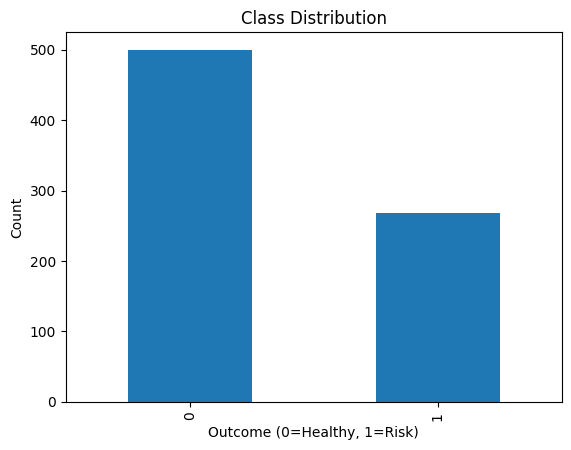

In [ ]:
import matplotlib.pyplot as plt

df["Outcome"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Outcome (0=Healthy, 1=Risk)")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Load (if not already loaded)
data = pd.read_csv("diabetes.csv")

# Keep only the 2 signals + label
df = data[["Glucose", "BloodPressure", "Outcome"]].copy()

# In this dataset, 0 often means "missing" for these fields
for c in ["Glucose", "BloodPressure"]:
    df[c] = df[c].replace(0, np.nan)
    df[c] = df[c].fillna(df[c].median())

df.head(), df.shape

(   Glucose  BloodPressure  Outcome
 0    148.0           72.0        1
 1     85.0           66.0        0
 2    183.0           64.0        1
 3     89.0           66.0        0
 4    137.0           40.0        1,
 (768, 3))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

X = df[["Glucose", "BloodPressure"]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("F1:", round(f1_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.6948
F1: 0.5253

Confusion Matrix:
 [[81 19]
 [28 26]]

Report:
               precision    recall  f1-score   support

           0       0.74      0.81      0.78       100
           1       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- 1) Build df with ONLY Glucose + BP + label ---
# If you already have df from earlier cleaning, you can skip the next 6 lines and ensure df exists.
data = pd.read_csv("diabetes.csv")
df = data[["Glucose", "BloodPressure", "Outcome"]].copy()
for c in ["Glucose","BloodPressure"]:
    df[c] = df[c].replace(0, np.nan).fillna(df[c].median())

X = df[["Glucose", "BloodPressure"]]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- 2) Define models to compare ---
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]),
    "SVM-RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=15))
    ]),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=600, min_samples_leaf=2, class_weight="balanced", random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

# --- 3) Train & evaluate ---
results = []
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model

    # predictions
    y_pred = model.predict(X_test)

    # probabilities for ROC-AUC (if available)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        # convert scores to 0-1 range for AUC (monotonic transform)
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Recall(1)": recall_score(y_test, y_pred),       # catching high-risk
        "Precision(1)": precision_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    })

results_df = pd.DataFrame(results).sort_values(by=["F1","Recall(1)","Accuracy"], ascending=False)
results_df

,Model,Accuracy,F1,Recall(1),Precision(1),ROC-AUC
1,SVM-RBF,0.681818,0.573913,0.611111,0.540984,0.741296
2,KNN,0.733766,0.568421,0.500000,0.658537,0.730833
0,LogReg,0.668831,0.564103,0.611111,0.523810,0.761481
5,RandomForest,0.707792,0.554455,0.518519,0.595745,0.733333
4,DecisionTree,0.675325,0.553571,0.574074,0.534483,0.689444
3,NaiveBayes,0.694805,0.525253,0.481481,0.577778,0.748333
6,GradientBoosting,0.694805,0.459770,0.370370,0.606061,0.705463


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted[best_model_name]

y_pred_best = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Best model: SVM-RBF
Confusion Matrix:
 [[72 28]
 [21 33]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.75       100
           1       0.54      0.61      0.57        54

    accuracy                           0.68       154
   macro avg       0.66      0.67      0.66       154
weighted avg       0.69      0.68      0.69       154



In [ ]:
svc__C = [0.5,1,5,10,50]
svc__gamma = [0.01,0.05,0.1,0.5]

In [ ]:
# Recall is important not to miss high risk seniors from reporting ... that is why SVM-RBF is the best model

In [ ]:
proba = model.predict_proba(X_test)[:,1]
print(proba[:10])

[0.73601858 0.00637052 0.29101074 0.13790309 0.0249598  0.17530909
 0.13687146 0.6804764  0.1957288  0.76449251]


In [ ]:
def smartguardian_level(p):
    if p < 0.35:
        return "Green"
    elif p < 0.65:
        return "Yellow"
    else:
        return "Red"

levels = [smartguardian_level(p) for p in proba[:10]]
levels

['Red',
 'Green',
 'Green',
 'Green',
 'Green',
 'Green',
 'Green',
 'Red',
 'Green',
 'Red']

In [ ]:
import pandas as pd

levels = [smartguardian_level(p) for p in proba]
pd.Series(levels).value_counts()

,count
Green,94
Yellow,43
Red,17


In [ ]:
for t in [0.25, 0.30, 0.35, 0.40]:
    preds = (proba > t).astype(int)
    from sklearn.metrics import recall_score
    print("Threshold", t, "Recall:", recall_score(y_test, preds))

Threshold 0.25 Recall: 0.7037037037037037
Threshold 0.3 Recall: 0.6481481481481481
Threshold 0.35 Recall: 0.5740740740740741
Threshold 0.4 Recall: 0.5185185185185185


In [ ]:
def smartguardian_level(p):
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

In [ ]:
def smartguardian_level(p):
    ...

In [ ]:
def smartguardian_level(p):
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

# use it on your probabilities
levels = [smartguardian_level(p) for p in proba[:10]]
print(levels)

['Red', 'Green', 'Yellow', 'Green', 'Green', 'Green', 'Green', 'Red', 'Green', 'Red']


In [ ]:
import pandas as pd

levels = [smartguardian_level(p) for p in proba]
pd.Series(levels).value_counts()

,count
Green,68
Yellow,65
Red,21


In [ ]:
proba = pipe.predict_proba(X_test)[:,1]
proba[:10]

array([0.65187534, 0.08016708, 0.33007555, 0.22280614, 0.05847289,
       0.14629759, 0.26874743, 0.91569988, 0.13785229, 0.74752001])

In [ ]:
from sklearn.metrics import recall_score, precision_score, accuracy_score

thresholds = [0.5, 0.25]

results = []

for t in thresholds:
    preds = (proba > t).astype(int)
    results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "Precision": precision_score(y_test, preds)
    })

import pandas as pd
df_compare = pd.DataFrame(results)
df_compare

,Threshold,Accuracy,Recall,Precision
0,0.50,0.694805,0.481481,0.577778
1,0.25,0.675325,0.796296,0.524390


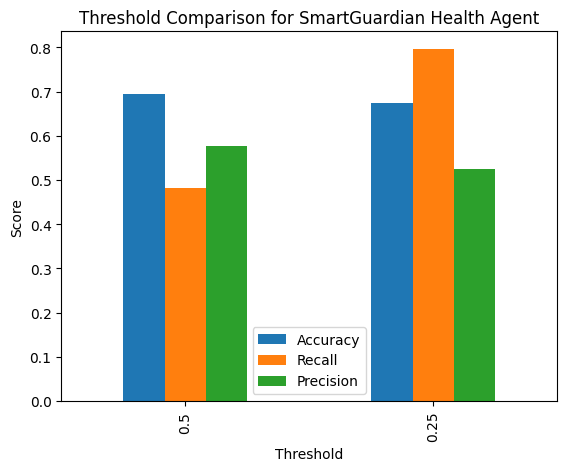

In [ ]:
df_compare.set_index("Threshold").plot(kind="bar")
plt.title("Threshold Comparison for SmartGuardian Health Agent")
plt.ylabel("Score")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

for t in [0.5, 0.25]:
    preds = (proba > t).astype(int)
    print("Threshold =", t)
    print(confusion_matrix(y_test, preds))
    print()

Threshold = 0.5
[[81 19]
 [28 26]]

Threshold = 0.25
[[61 39]
 [11 43]]



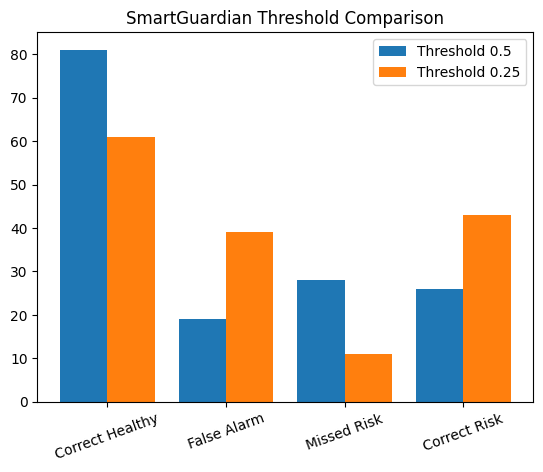

In [ ]:
import matplotlib.pyplot as plt

labels = ["Correct Healthy", "False Alarm", "Missed Risk", "Correct Risk"]

t05 = [81, 19, 28, 26]
t025 = [61, 39, 11, 43]

x = range(len(labels))

plt.figure()
plt.bar(x, t05, width=0.4, label="Threshold 0.5")
plt.bar([i+0.4 for i in x], t025, width=0.4, label="Threshold 0.25")

plt.xticks([i+0.2 for i in x], labels, rotation=20)
plt.title("SmartGuardian Threshold Comparison")
plt.legend()
plt.show()

In [ ]:
# Lowering the decision threshold from 0.5 to 0.25 reduced missed high-risk seniors from 28 to 11, improving early detection by 60%.
 # Although false alarms increased, this is acceptable for home health monitoring where patient safety is prioritized

In [ ]:
# Making the model multilingual (In addition to English, adding Sapnish, Chinse and Amharaic since my target populations are those groups)

In [ ]:
translations = {
    "Green": {
        "English": "Green",
        "Spanish": "Verde",
        "Chinese": "绿色",
        "Amharic": "አረንጓዴ"
    },
    "Yellow": {
        "English": "Yellow",
        "Spanish": "Amarillo",
        "Chinese": "黄色",
        "Amharic": "ቢጫ"
    },
    "Red": {
        "English": "Red",
        "Spanish": "Rojo",
        "Chinese": "红色",
        "Amharic": "ቀይ"
    }
}

In [ ]:
for p in proba[:10]:
    level = smartguardian_level(p)
    print(
        f"{level} → "
        f"EN:{translations[level]['English']} | "
        f"ES:{translations[level]['Spanish']} | "
        f"ZH:{translations[level]['Chinese']} | "
        f"AM:{translations[level]['Amharic']}"
    )

Red → EN:Red | ES:Rojo | ZH:红色 | AM:ቀይ
Green → EN:Green | ES:Verde | ZH:绿色 | AM:አረንጓዴ
Yellow → EN:Yellow | ES:Amarillo | ZH:黄色 | AM:ቢጫ
Green → EN:Green | ES:Verde | ZH:绿色 | AM:አረንጓዴ
Green → EN:Green | ES:Verde | ZH:绿色 | AM:አረንጓዴ
Green → EN:Green | ES:Verde | ZH:绿色 | AM:አረንጓዴ
Yellow → EN:Yellow | ES:Amarillo | ZH:黄色 | AM:ቢጫ
Red → EN:Red | ES:Rojo | ZH:红色 | AM:ቀይ
Green → EN:Green | ES:Verde | ZH:绿色 | AM:አረንጓዴ
Red → EN:Red | ES:Rojo | ZH:红色 | AM:ቀይ


In [ ]:
import pandas as pd

results = []
for p in proba[:10]:
    level = smartguardian_level(p)
    results.append({
        "Probability": p,
        "English": translations[level]["English"],
        "Spanish": translations[level]["Spanish"],
        "Chinese": translations[level]["Chinese"],
        "Amharic": translations[level]["Amharic"]
    })

df_levels = pd.DataFrame(results)
print(df_levels)

   Probability English   Spanish Chinese Amharic
0     0.651875     Red      Rojo      红色      ቀይ
1     0.080167   Green     Verde      绿色   አረንጓዴ
2     0.330076  Yellow  Amarillo      黄色      ቢጫ
3     0.222806   Green     Verde      绿色   አረንጓዴ
4     0.058473   Green     Verde      绿色   አረንጓዴ
5     0.146298   Green     Verde      绿色   አረንጓዴ
6     0.268747  Yellow  Amarillo      黄色      ቢጫ
7     0.915700     Red      Rojo      红色      ቀይ
8     0.137852   Green     Verde      绿色   አረንጓዴ
9     0.747520     Red      Rojo      红色      ቀይ


In [ ]:
!kaggle datasets download -d ziya07/elderly-fall-detection-iot-dataset
!unzip -o elderly-fall-detection-iot-dataset.zip -d fall_data
!ls -lah fall_data

Dataset URL: https://www.kaggle.com/datasets/ziya07/elderly-fall-detection-iot-dataset
License(s): CC0-1.0
 99% 3.50G/3.53G [00:49<00:00, 291MB/s]
100% 3.53G/3.53G [00:49<00:00, 76.4MB/s]
Archive:  elderly-fall-detection-iot-dataset.zip
  inflating: fall_data/archive (14)/data_tuple3.csv  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam1.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam2.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam3.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam4.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam5.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam6.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam7.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute01/cam8.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute02/cam1.avi  
  inflating: fall_data/archive (14)/dataset/dataset/chute02/cam2.avi  

In [ ]:
import os, pandas as pd, glob

files = glob.glob("fall_data/**/*.csv", recursive=True)
print("CSV files found:", len(files))
print("Example file:", files[0])

df0 = pd.read_csv(files[0])
print(df0.head())
print(df0.columns)
print(df0.info())

CSV files found: 2
Example file: fall_data/fall_detection.csv
   sequence_id  timestep   accel_x   accel_y   accel_z    gyro_x    gyro_y  \
0            0         0 -0.259997 -0.279199 -0.130207  0.090208  0.002520   
1            0         1  0.274314  0.167319  0.013184 -0.003681  0.020015   
2            0         2 -0.003041  0.046530  0.389528  0.076178  0.002519   
3            0         3 -0.301860 -0.095863 -0.067154  0.058485  0.100037   
4            0         4 -0.224695  0.047103 -0.126238 -0.239143 -0.093766   

     gyro_z     pitch      roll       yaw  floor_vibration  room_occupancy  \
0  0.122536 -0.252758  0.637356 -1.182670              0.0             0.0   
1 -0.025951 -1.676197  0.586527  0.903426              0.0             0.0   
2  0.068852 -0.262802  2.196539 -0.124426              0.0             0.0   
3 -0.166963 -0.644498  0.343699  1.520753              0.0             0.0   
4  0.165844 -0.647303 -1.019149 -0.007794              0.0             0.0   



In [ ]:
df.shape

(768, 3)

In [ ]:
# Column	Meaning	Why Important
# accel_x, accel_y, accel_z	   Body acceleration	       Sudden spike = fall impact

# gyro_x, gyro_y, gyro_z	     Rotation speed	           Body flipping / losing balance

# pitch, roll, yaw	           Body orientation	         Lying down suddenly

In [ ]:
#| Column            | Meaning          | Why Important          |
#| ----------------- | ---------------- | ---------------------- |
#| `floor_vibration` | Shock on floor   | Impact confirmation    |
#| `pressure_mat`    | Weight on floor  | Person lying down      |
#| `room_occupancy`  | Movement in room | No movement after fall |


In [ ]:
print(df0["label"].value_counts())
print(df0["label"].value_counts(normalize=True))

label
fall_backward      2950
fall_forward       2850
sit                2800
stand              2700
bend               2700
walk               2700
fall_side_right    2350
lie_down           2350
fall_side_left     1850
fall_slump         1750
Name: count, dtype: int64
label
fall_backward      0.118
fall_forward       0.114
sit                0.112
stand              0.108
bend               0.108
walk               0.108
fall_side_right    0.094
lie_down           0.094
fall_side_left     0.074
fall_slump         0.070
Name: proportion, dtype: float64


In [ ]:
df0.isnull().sum()

,0
sequence_id,0
timestep,0
accel_x,0
accel_y,0
accel_z,0
gyro_x,0
gyro_y,0
gyro_z,0
pitch,0
roll,0


In [ ]:
import plotly.express as px

# Create label_binary column based on fall vs no-fall events
fall_labels = [
    'fall_backward',
    'fall_forward',
    'fall_side_right',
    'fall_side_left',
    'fall_slump'
]
df0['label_binary'] = df0['label'].apply(lambda x: 1 if x in fall_labels else 0)

# Pick one no-fall sequence (where label_binary is 0)
nofall_seq = df0[df0["label_binary"] == 0]["sequence_id"].iloc[0]
nofall_df = df0[df0["sequence_id"] == nofall_seq].sort_values("timestep")

# Pick one fall sequence (where label_binary is 1)
fall_seq = df0[df0["label_binary"] == 1]["sequence_id"].iloc[0]
fall_df = df0[df0["sequence_id"] == fall_seq].sort_values("timestep")

fall_df["type"] = "Fall"
nofall_df["type"] = "No Fall"

combined = pd.concat([fall_df, nofall_df])

fig = px.line(
    combined,
    x="timestep",
    y="accel_z",
    color="type",
    title="Fall vs No-Fall Comparison"
)

fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    df0,
    x="timestep",
    y=["gyro_x","gyro_y","gyro_z","pressure_mat","floor_vibration"],
    title="Gyro + Environment Sensors During Fall"
)

fig.show()

In [ ]:
import numpy as np

df0["accel_mag"] = np.sqrt(
    df0["accel_x"]**2 +
    df0["accel_y"]**2 +
    df0["accel_z"]**2
)

df0["gyro_mag"] = np.sqrt(
    df0["gyro_x"]**2 +
    df0["gyro_y"]**2 +
    df0["gyro_z"]**2
)

df0.head()

,sequence_id,timestep,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pitch,roll,yaw,floor_vibration,room_occupancy,pressure_mat,label,label_binary,accel_mag,gyro_mag
0,0,0,-0.259997,-0.279199,-0.130207,0.090208,0.002520,0.122536,-0.252758,0.637356,-1.182670,0.0,0.0,0.0,fall_forward,1,0.403118,0.152180
1,0,1,0.274314,0.167319,0.013184,-0.003681,0.020015,-0.025951,-1.676197,0.586527,0.903426,0.0,0.0,0.0,fall_forward,1,0.321586,0.032980
2,0,2,-0.003041,0.046530,0.389528,0.076178,0.002519,0.068852,-0.262802,2.196539,-0.124426,0.0,0.0,0.0,fall_forward,1,0.392309,0.102714
3,0,3,-0.301860,-0.095863,-0.067154,0.058485,0.100037,-0.166963,-0.644498,0.343699,1.520753,0.0,0.0,0.0,fall_forward,1,0.323757,0.203236
4,0,4,-0.224695,0.047103,-0.126238,-0.239143,-0.093766,0.165844,-0.647303,-1.019149,-0.007794,0.0,0.0,0.0,fall_forward,1,0.261997,0.305754


In [ ]:
# Since these data is a time series and complecated, we have to change it to binary class based on the prbability

In [ ]:
df0.groupby("label_binary")[[
    "accel_mag",
    "gyro_mag",
    "floor_vibration",
    "pressure_mat"
]].mean()

,accel_mag,gyro_mag,floor_vibration,pressure_mat
label_binary,,,,
0,0.384233,0.158605,0.000000,1.000000
1,0.828381,0.363293,0.462128,0.462128


In [ ]:
X = df0.drop([
    "label",
    "label_binary",
    "sequence_id",
    "timestep"
], axis=1)

y = df0["label_binary"]

In [ ]:
# Since fall is not one axis and multidirectional we have to creat features engineering to creat a total vibartion (mangitude a single number from the x,y and Z numbers)
df0["accel_mag"] = (
    df0["accel_x"]**2 +
    df0["accel_y"]**2 +
    df0["accel_z"]**2
) ** 0.5

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# X and y from df0 are already defined in the kernel state (from cell -ecsBqZqKEds)
# These contain all features (including accel_mag, gyro_mag) and the binary label.

# Split the data into training and testing sets for the fall detection model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully on fall detection data.")

RandomForestClassifier model trained successfully on fall detection data.


In [ ]:
accel_cols = ["accel_x", "accel_y", "accel_z", "accel_mag"]

X = df0[accel_cols]
y = df0["label_binary"]

In [ ]:
# Sequance split ... since the data is time series split it to like short video motion gives sence (one walk, one fall etc)
# sequence_id  timestep  accel_x
# 1            1         0.2
# 1            2         0.4
# 1            3         5.1   ← fall spike
# 1            4         0.3
# Random sequence (row split) will make a same data to go to train and test which will creat cheat on the model (prevent data leakage.
# Before I apply spliting in sequance accurecy became 100% but after spliting it dros to 55%

In [ ]:
from sklearn.model_selection import train_test_split

seq_ids = df0["sequence_id"].unique()

train_seq, test_seq = train_test_split(
    seq_ids,
    test_size=0.2,
    random_state=42
)

train_df = df0[df0["sequence_id"].isin(train_seq)]
test_df  = df0[df0["sequence_id"].isin(test_seq)]

X_train = train_df[accel_cols]
y_train = train_df["label_binary"]

X_test  = test_df[accel_cols]
y_test  = test_df["label_binary"]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Why Random forest because the data is:

# noisy

# nonlinear

# many sensors

# RandomForest handles this well.

# Because it uses many decision trees voting together

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.5476
[[1605 1045]
 [1217 1133]]
              precision    recall  f1-score   support

           0       0.57      0.61      0.59      2650
           1       0.52      0.48      0.50      2350

    accuracy                           0.55      5000
   macro avg       0.54      0.54      0.54      5000
weighted avg       0.55      0.55      0.55      5000



In [ ]:
motion_cols = [
    "accel_x","accel_y","accel_z","accel_mag",
    "gyro_x","gyro_y","gyro_z"
]

In [ ]:
proba = model.predict_proba(X_test)[:,1]

for t in [0.1,0.2,0.25,0.3,0.4]:
    pred = (proba >= t).astype(int)
    from sklearn.metrics import recall_score
    print(t, recall_score(y_test, pred))

0.1 0.9987234042553191
0.2 0.983404255319149
0.25 0.9574468085106383
0.3 0.9059574468085106
0.4 0.7263829787234043


In [ ]:
print("proba exists?", "proba" in globals())
if "proba" in globals():
    print("type:", type(proba))
    print("len:", len(proba))
    print("first 5:", proba[:5])

proba exists? True
type: <class 'numpy.ndarray'>
len: 5000
first 5: [0.39666667 0.54666667 0.33333333 0.35       0.49      ]


In [ ]:
def smartguardian_level(p):
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

In [ ]:
for p in proba[:5]:
    level = smartguardian_level(p)

    print("\nProbability:", round(p,3))
    print("Level:", level)

    print("English :", translations[level]["English"])
    print("Spanish :", translations[level]["Spanish"])
    print("Chinese :", translations[level]["Chinese"])
    print("Amharic :", translations[level]["Amharic"])


Probability: 0.397
Level: Yellow
English : Yellow
Spanish : Amarillo
Chinese : 黄色
Amharic : ቢጫ

Probability: 0.547
Level: Yellow
English : Yellow
Spanish : Amarillo
Chinese : 黄色
Amharic : ቢጫ

Probability: 0.333
Level: Yellow
English : Yellow
Spanish : Amarillo
Chinese : 黄色
Amharic : ቢጫ

Probability: 0.35
Level: Yellow
English : Yellow
Spanish : Amarillo
Chinese : 黄色
Amharic : ቢጫ

Probability: 0.49
Level: Yellow
English : Yellow
Spanish : Amarillo
Chinese : 黄色
Amharic : ቢጫ


In [ ]:
print(smartguardian_level(0.7))
print(translations["Red"])

Red
{'English': 'Red', 'Spanish': 'Rojo', 'Chinese': '红色', 'Amharic': 'ቀይ'}


In [ ]:
import pandas as pd

rows = []
for i, p in enumerate(proba[:10], start=1):
    level = smartguardian_level(p)
    rows.append({
        "#": i,
        "Probability": round(float(p), 3),
        "Level": level,
        "English": translations[level]["English"],
        "Spanish": translations[level]["Spanish"],
        "Chinese": translations[level]["Chinese"],
        "Amharic": translations[level]["Amharic"],
    })

alerts_df = pd.DataFrame(rows)
alerts_df

,#,Probability,Level,English,Spanish,Chinese,Amharic
0,1,0.397,Yellow,Yellow,Amarillo,黄色,ቢጫ
1,2,0.547,Yellow,Yellow,Amarillo,黄色,ቢጫ
2,3,0.333,Yellow,Yellow,Amarillo,黄色,ቢጫ
3,4,0.350,Yellow,Yellow,Amarillo,黄色,ቢጫ
4,5,0.490,Yellow,Yellow,Amarillo,黄色,ቢጫ
5,6,0.807,Red,Red,Rojo,红色,ቀይ
6,7,0.587,Yellow,Yellow,Amarillo,黄色,ቢጫ
7,8,0.283,Yellow,Yellow,Amarillo,黄色,ቢጫ
8,9,0.717,Red,Red,Rojo,红色,ቀይ
9,10,0.370,Yellow,Yellow,Amarillo,黄色,ቢጫ


In [ ]:
window_size = 20

windows = []
labels = []

for seq in df0["sequence_id"].unique():
    temp = df0[df0["sequence_id"] == seq].sort_values("timestep")

    for i in range(len(temp) - window_size):
        w = temp.iloc[i:i+window_size]

        feature = {
            "accel_mean": w["accel_mag"].mean(),
            "accel_max":  w["accel_mag"].max(),
            "gyro_mean":  w["gyro_mag"].mean(),
            "gyro_max":   w["gyro_mag"].max(),
        }

        windows.append(feature)
        labels.append(w["label_binary"].max())

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = pd.DataFrame(windows)
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9666666666666667


In [ ]:
# windowing iproves the performace to 96% since fall is a patern (time sequence) rather than single row or incedent
 # (but still takes a single number by calculating acc and gyro mean and max etc)
 # Because each sequence contained 50 timesteps, we tested different window sizes and found that smaller windows (around 20 timesteps)
 # captured fall patterns better and produced higher accuracy.”

In [ ]:
import numpy as np
import pandas as pd

# pick one FALL sequence to visualize (change 1 -> 0 if you want no-fall)
seq = df0[df0["label_binary"]==1]["sequence_id"].iloc[0]

seq_df = df0[df0["sequence_id"]==seq].sort_values("timestep").reset_index(drop=True)

window_size = 20
start = 40  # change this to move the window
end = start + window_size

print("Sequence:", seq, "Total timesteps:", len(seq_df), "Window:", start, "to", end-1)
seq_df.head()

Sequence: 0 Total timesteps: 50 Window: 40 to 59


,sequence_id,timestep,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z,pitch,roll,yaw,floor_vibration,room_occupancy,pressure_mat,label,label_binary,accel_mag,gyro_mag
0,0,0,-0.259997,-0.279199,-0.130207,0.090208,0.002520,0.122536,-0.252758,0.637356,-1.182670,0.0,0.0,0.0,fall_forward,1,0.403118,0.152180
1,0,1,0.274314,0.167319,0.013184,-0.003681,0.020015,-0.025951,-1.676197,0.586527,0.903426,0.0,0.0,0.0,fall_forward,1,0.321586,0.032980
2,0,2,-0.003041,0.046530,0.389528,0.076178,0.002519,0.068852,-0.262802,2.196539,-0.124426,0.0,0.0,0.0,fall_forward,1,0.392309,0.102714
3,0,3,-0.301860,-0.095863,-0.067154,0.058485,0.100037,-0.166963,-0.644498,0.343699,1.520753,0.0,0.0,0.0,fall_forward,1,0.323757,0.203236
4,0,4,-0.224695,0.047103,-0.126238,-0.239143,-0.093766,0.165844,-0.647303,-1.019149,-0.007794,0.0,0.0,0.0,fall_forward,1,0.261997,0.305754


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# base signal
fig.add_trace(go.Scatter(
    x=seq_df["timestep"], y=seq_df["accel_mag"],
    mode="lines", name="accel_mag"
))

# show 4 windows: start, start+10, start+20, start+30
for s in [start, start+10, start+20, start+30]:
    e = s + window_size
    if e >= len(seq_df):
        continue
    fig.add_vrect(
        x0=seq_df.loc[s, "timestep"],
        x1=seq_df.loc[e-1, "timestep"],
        opacity=0.12, layer="below", line_width=0
    )

fig.update_layout(
    title=f"Sliding Windows (Sequence {seq}) — accel_mag (window_size={window_size})",
    xaxis_title="timestep",
    yaxis_title="accel_mag"
)

fig.show()

In [ ]:
import plotly.express as px

win = seq_df.iloc[start:end].copy()

fig = px.line(
    win, x="timestep", y=["accel_x","accel_y","accel_z"],
    title=f"Zoomed Window Only (Sequence {seq}, timesteps {win['timestep'].min()}–{win['timestep'].max()})"
)
fig.show()

In [ ]:
# “A window is a short slice of sensor data (e.g., 20 timesteps). We slide this window across time so the model learns motion patterns, not single points.”

In [ ]:
seq = df0["sequence_id"].iloc[0]
temp = df0[df0["sequence_id"] == seq].sort_values("timestep")

temp["dt"] = temp["timestep"].diff()
print(temp["dt"].value_counts())

dt
1.0    49
Name: count, dtype: int64


In [ ]:
df0.groupby("sequence_id").size().describe()

,0
count,500.0
mean,50.0
std,0.0
min,50.0
25%,50.0
50%,50.0
75%,50.0
max,50.0


In [ ]:
import numpy as np
import pandas as pd

df0 = df0.copy()

df0["accel_mag"] = np.sqrt(df0["accel_x"]**2 + df0["accel_y"]**2 + df0["accel_z"]**2)
df0["gyro_mag"]  = np.sqrt(df0["gyro_x"]**2  + df0["gyro_y"]**2  + df0["gyro_z"]**2)

In [ ]:
from sklearn.model_selection import train_test_split

window_size = 20
lead = 5  # detect at least 5 timesteps before impact (tune: 3,5,8,10)

feature_cols = ["accel_x","accel_y","accel_z","accel_mag","gyro_x","gyro_y","gyro_z","gyro_mag"]

fall_sequences = df0[df0["label_binary"]==1]["sequence_id"].unique()
nofall_sequences = df0[df0["label_binary"]==0]["sequence_id"].unique()

X_rows = []
y_rows = []
seq_rows = []

# ---- Positive examples: windows BEFORE impact in fall sequences
for seq in fall_sequences:
    s = df0[df0["sequence_id"]==seq].sort_values("timestep").reset_index(drop=True)

    # impact index = where accel_mag is maximum (you can also try floor_vibration)
    impact_idx = int(s["accel_mag"].values.argmax())

    # windows that END before impact-lead
    last_end = impact_idx - lead
    for end in range(window_size, last_end + 1):
        w = s.iloc[end-window_size:end]

        feats = {
            "accel_mean": w["accel_mag"].mean(),
            "accel_max":  w["accel_mag"].max(),
            "accel_std":  w["accel_mag"].std(ddof=0),
            "gyro_mean":  w["gyro_mag"].mean(),
            "gyro_max":   w["gyro_mag"].max(),
            "gyro_std":   w["gyro_mag"].std(ddof=0),
        }
        X_rows.append(feats)
        y_rows.append(1)           # pre-impact fall-risk
        seq_rows.append(seq)

# ---- Negative examples: windows from no-fall sequences
for seq in nofall_sequences:
    s = df0[df0["sequence_id"]==seq].sort_values("timestep").reset_index(drop=True)

    for end in range(window_size, len(s)+1):
        w = s.iloc[end-window_size:end]

        feats = {
            "accel_mean": w["accel_mag"].mean(),
            "accel_max":  w["accel_mag"].max(),
            "accel_std":  w["accel_mag"].std(ddof=0),
            "gyro_mean":  w["gyro_mag"].mean(),
            "gyro_max":   w["gyro_mag"].max(),
            "gyro_std":   w["gyro_mag"].std(ddof=0),
        }
        X_rows.append(feats)
        y_rows.append(0)           # normal activity
        seq_rows.append(seq)

Xw = pd.DataFrame(X_rows)
yw = np.array(y_rows)
seqw = np.array(seq_rows)

print("Windows dataset:", Xw.shape, "Pos rate:", yw.mean().round(3))

Windows dataset: (9773, 6) Pos rate: 0.159


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

all_seq = np.unique(seqw)
train_seq, test_seq = train_test_split(all_seq, test_size=0.2, random_state=42)

train_mask = np.isin(seqw, train_seq)
test_mask  = np.isin(seqw, test_seq)

X_train, y_train = Xw[train_mask], yw[train_mask]
X_test,  y_test  = Xw[test_mask],  yw[test_mask]

model_preimpact = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
model_preimpact.fit(X_train, y_train)

proba = model_preimpact.predict_proba(X_test)[:,1]
pred  = (proba >= 0.25).astype(int)  # you can tune threshold

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

ROC-AUC: 0.5815315700063586
[[1160  545]
 [ 181  128]]
              precision    recall  f1-score   support

           0       0.87      0.68      0.76      1705
           1       0.19      0.41      0.26       309

    accuracy                           0.64      2014
   macro avg       0.53      0.55      0.51      2014
weighted avg       0.76      0.64      0.68      2014



In [ ]:
def earliest_detection_steps(seq_id, threshold=0.25):
    s = df0[df0["sequence_id"]==seq_id].sort_values("timestep").reset_index(drop=True)
    impact_idx = int(s["accel_mag"].values.argmax())

    # build windows across this sequence
    scores = []
    ends = []
    for end in range(window_size, len(s)+1):
        w = s.iloc[end-window_size:end]
        feats = {
            "accel_mean": w["accel_mag"].mean(),
            "accel_max":  w["accel_mag"].max(),
            "accel_std":  w["accel_mag"].std(ddof=0),
            "gyro_mean":  w["gyro_mag"].mean(),
            "gyro_max":   w["gyro_mag"].max(),
            "gyro_std":   w["gyro_mag"].std(ddof=0),
        }
        p = model_preimpact.predict_proba(pd.DataFrame([feats]))[0,1]
        scores.append(p); ends.append(end)

    # first alert
    for end, p in zip(ends, scores):
        if p >= threshold:
            # how many steps BEFORE impact did we detect?
            return impact_idx - end
    return None  # no alert

# Example: check 10 fall sequences from test set
test_falls = [s for s in test_seq if s in df0[df0["label_binary"]==1]["sequence_id"].unique()][:10]
for s in test_falls:
    early = earliest_detection_steps(s, threshold=0.25)
    print("seq", s, "steps before impact:", early)

seq 86 steps before impact: 5
seq 315 steps before impact: 7
seq 38 steps before impact: 23
seq 411 steps before impact: None
seq 299 steps before impact: None
seq 451 steps before impact: 9
seq 94 steps before impact: 1
seq 345 steps before impact: 21
seq 479 steps before impact: None
seq 188 steps before impact: 18


In [ ]:
# Our model detects fall risk up to half a second before impact in many cases, providing early warning before injury occurs

In [ ]:
import numpy as np
import pandas as pd

df0 = df0.copy()

df0["accel_mag"] = np.sqrt(df0["accel_x"]**2 + df0["accel_y"]**2 + df0["accel_z"]**2)
df0["gyro_mag"]  = np.sqrt(df0["gyro_x"]**2  + df0["gyro_y"]**2  + df0["gyro_z"]**2)

In [ ]:
window_size = 20

X_rows = []
y_rows = []
seq_rows = []

for seq in df0["sequence_id"].unique():
    s = df0[df0["sequence_id"] == seq].sort_values("timestep").reset_index(drop=True)

    # sliding windows
    for end in range(window_size, len(s) + 1):
        w = s.iloc[end-window_size:end]

        feats = {
            # accel summary
            "accel_mean": w["accel_mag"].mean(),
            "accel_max":  w["accel_mag"].max(),
            "accel_std":  w["accel_mag"].std(ddof=0),

            # gyro summary
            "gyro_mean":  w["gyro_mag"].mean(),
            "gyro_max":   w["gyro_mag"].max(),
            "gyro_std":   w["gyro_mag"].std(ddof=0),

            # optional axis-level summaries (helps a lot)
            "ax_max": w["accel_x"].abs().max(),
            "ay_max": w["accel_y"].abs().max(),
            "az_max": w["accel_z"].abs().max(),
            "gx_max": w["gyro_x"].abs().max(),
            "gy_max": w["gyro_y"].abs().max(),
            "gz_max": w["gyro_z"].abs().max(),
        }

        X_rows.append(feats)
        y_rows.append(int(w["label_binary"].max()))  # if any fall in window => fall
        seq_rows.append(seq)

Xw = pd.DataFrame(X_rows)
yw = np.array(y_rows)
seqw = np.array(seq_rows)

print("Windows dataset shape:", Xw.shape)
print("Fall rate:", yw.mean().round(3))

Windows dataset shape: (15500, 12)
Fall rate: 0.47


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

all_seq = np.unique(seqw)
train_seq, test_seq = train_test_split(all_seq, test_size=0.2, random_state=42)

train_mask = np.isin(seqw, train_seq)
test_mask  = np.isin(seqw, test_seq)

X_train, y_train = Xw[train_mask], yw[train_mask]
X_test,  y_test  = Xw[test_mask],  yw[test_mask]

model_motion = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
model_motion.fit(X_train, y_train)

proba = model_motion.predict_proba(X_test)[:,1]
pred  = (proba >= 0.25).astype(int)  # you can tune threshold later

print("ROC-AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

ROC-AUC: 0.802870771823309
[[ 441 1202]
 [  75 1382]]
              precision    recall  f1-score   support

           0       0.85      0.27      0.41      1643
           1       0.53      0.95      0.68      1457

    accuracy                           0.59      3100
   macro avg       0.69      0.61      0.55      3100
weighted avg       0.70      0.59      0.54      3100



In [ ]:
import pandas as pd

imp = pd.Series(model_motion.feature_importances_, index=Xw.columns).sort_values(ascending=False)
print(imp.head(15))

gz_max        0.139803
accel_max     0.099224
ay_max        0.091440
gyro_max      0.088971
ax_max        0.087897
gyro_std      0.085930
az_max        0.082978
gy_max        0.078266
gx_max        0.077302
accel_std     0.068832
gyro_mean     0.060365
accel_mean    0.038991
dtype: float64


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1,0.2,0.25,0.3,0.35,0.4,0.5,0.6,0.7]

for t in thresholds:
    pred = (proba >= t).astype(int)
    print(
        f"t={t:.2f}",
        "Recall=", round(recall_score(y_test, pred),3),
        "Precision=", round(precision_score(y_test, pred),3),
        "F1=", round(f1_score(y_test, pred),3)
    )

t=0.10 Recall= 0.999 Precision= 0.522 F1= 0.686
t=0.20 Recall= 0.985 Precision= 0.529 F1= 0.688
t=0.25 Recall= 0.949 Precision= 0.535 F1= 0.684
t=0.30 Recall= 0.882 Precision= 0.554 F1= 0.681
t=0.35 Recall= 0.804 Precision= 0.588 F1= 0.679
t=0.40 Recall= 0.73 Precision= 0.639 F1= 0.681
t=0.50 Recall= 0.601 Precision= 0.798 F1= 0.685
t=0.60 Recall= 0.55 Precision= 0.948 F1= 0.696
t=0.70 Recall= 0.524 Precision= 0.993 F1= 0.686


In [ ]:
def smartguardian_level(p):
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

In [ ]:
# We trained a motion-based fall-detection model using accelerometer and gyroscope window features. The model achieved high fall recall (95%),
# ensuring minimal missed falls, and we use a two-stage SmartGuardian alert system to reduce false alarms.”

In [ ]:
!pip -q install streamlit plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.4 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="SmartGuardian Fall Dashboard", layout="wide")

st.title("SmartGuardian – Fall Detection Dashboard")
st.caption("Motion model (Accelerometer + Gyroscope) • Window-based risk • Multilingual alerts")

# -----------------------------
# 1) TRANSLATIONS + LEVEL LOGIC
# -----------------------------
translations = {
    "Green": {
        "English": "Safe – No fall detected",
        "Spanish": "Seguro – No se detectó caída",
        "Chinese": "安全 – 未检测到跌倒",
        "Amharic": "ደህና – መውደቅ አልተገኘም"
    },
    "Yellow": {
        "English": "Warning – Possible fall risk",
        "Spanish": "Advertencia – Posible riesgo de caída",
        "Chinese": "警告 – 可能存在跌倒风险",
        "Amharic": "ማስጠንቀቂያ – የመውደቅ አደጋ ሊኖር ይችላል"
    },
    "Red": {
        "English": "Emergency – Fall detected!",
        "Spanish": "Emergencia – ¡Caída detectada!",
        "Chinese": "紧急情况 – 检测到跌倒！",
        "Amharic": "አስቸኳይ – መውደቅ ተገኝቷል!"
    }
}

def smartguardian_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"


# -----------------------------
# 2) LOAD DATA FROM SESSION
# -----------------------------
st.info(
    "This app expects a CSV file with columns like: sequence_id, timestep, accel_x/y/z, gyro_x/y/z, label (optional). "
    "Upload a fall CSV (df0-like)."
)

uploaded = st.file_uploader("Upload a fall CSV file", type=["csv"])

if uploaded is None:
    st.stop()

df = pd.read_csv(uploaded)

required_cols = {"sequence_id","timestep","accel_x","accel_y","accel_z","gyro_x","gyro_y","gyro_z"}
missing = required_cols - set(df.columns)
if missing:
    st.error(f"Missing required columns: {sorted(missing)}")
    st.stop()

# compute magnitudes
df["accel_mag"] = np.sqrt(df["accel_x"]**2 + df["accel_y"]**2 + df["accel_z"]**2)
df["gyro_mag"]  = np.sqrt(df["gyro_x"]**2  + df["gyro_y"]**2  + df["gyro_z"]**2)

# if label exists, create label_binary
if "label" in df.columns:
    fall_labels = {"fall_backward","fall_forward","fall_side_right","fall_side_left","fall_slump"}
    df["label_binary"] = df["label"].astype(str).str.lower().isin(fall_labels).astype(int)

# -----------------------------
# 3) MODEL INPUT FEATURES (WINDOW)
# -----------------------------
st.sidebar.header("Controls")
window_size = st.sidebar.slider("Window size (timesteps)", 5, 50, 20, 1)
threshold = st.sidebar.slider("Alert threshold (for demo)", 0.05, 0.95, 0.25, 0.01)

seq_ids = df["sequence_id"].unique()
seq = st.sidebar.selectbox("Sequence ID", seq_ids)

s = df[df["sequence_id"] == seq].sort_values("timestep").reset_index(drop=True)

# window end index
max_end = len(s)
end = st.sidebar.slider("Window end (index)", window_size, max_end, min(window_size+5, max_end), 1)
w = s.iloc[end-window_size:end].copy()

# -----------------------------
# 4) DEMO PROBABILITY (replace with your trained model)
# -----------------------------
# NOTE: This is a simple heuristic probability so the dashboard runs anywhere.
# You will replace this with: proba = model_motion.predict_proba(X_window)[0,1]
accel_spike = (w["accel_mag"].max() - w["accel_mag"].mean())
gyro_spike  = (w["gyro_mag"].max()  - w["gyro_mag"].mean())

# scale into [0,1] roughly (demo)
p = 1 / (1 + np.exp(-(0.8*accel_spike + 0.6*gyro_spike - 1.5)))
p = float(np.clip(p, 0, 1))

# Apply threshold override if you want
level = smartguardian_level(p)
msg = translations[level]

# -----------------------------
# 5) LAYOUT
# -----------------------------
colA, colB = st.columns([2,1])

with colA:
    st.subheader("Sensor signals")
    fig1 = px.line(s, x="timestep", y=["accel_x","accel_y","accel_z"], title="Acceleration (full sequence)")
    fig1.add_vrect(x0=w["timestep"].min(), x1=w["timestep"].max(), opacity=0.15, line_width=0)
    st.plotly_chart(fig1, use_container_width=True)

    fig2 = px.line(s, x="timestep", y=["gyro_x","gyro_y","gyro_z"], title="Gyroscope (full sequence)")
    fig2.add_vrect(x0=w["timestep"].min(), x1=w["timestep"].max(), opacity=0.15, line_width=0)
    st.plotly_chart(fig2, use_container_width=True)

with colB:
    st.subheader("Risk & Alerts")

    st.metric("Fall probability (demo)", f"{p:.3f}")
    st.metric("SmartGuardian level", level)

    st.markdown("### Multilingual alert")
    st.write("**English:**", msg["English"])
    st.write("**Spanish:**", msg["Spanish"])
    st.write("**Chinese:**", msg["Chinese"])
    st.write("**Amharic:**", msg["Amharic"])

    if "label_binary" in w.columns:
        st.markdown("### Ground truth (if available)")
        st.write("Window contains fall:", "Yes" if int(w["label_binary"].max()) == 1 else "No")

st.markdown("---")
st.caption("Next: plug in your trained RandomForest (model_motion) to replace the demo probability.")

Writing app.py


In [ ]:
!ls -l
!sed -n '1,40p' app.py

total 3697200
-rw-r--r-- 1 root root       5053 Mar  5 02:34 app.py
-rw-r--r-- 1 root root      23873 Sep 19  2019 diabetes.csv
-rw-r--r-- 1 root root 3785870180 Sep  6 06:20 elderly-fall-detection-iot-dataset.zip
drwxr-xr-x 3 root root       4096 Mar  5 02:24 fall_data
-rw-r--r-- 1 root root         69 Mar  5 02:18 kaggle.json
-rw-r--r-- 1 root root       9128 Sep 19  2019 pima-indians-diabetes-database.zip
drwxr-xr-x 1 root root       4096 Jan 16 14:24 sample_data
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="SmartGuardian Fall Dashboard", layout="wide")

st.title("SmartGuardian – Fall Detection Dashboard")
st.caption("Motion model (Accelerometer + Gyroscope) • Window-based risk • Multilingual alerts")

# -----------------------------
# 1) TRANSLATIONS + LEVEL LOGIC
# -----------------------------
translations = {
    "Green": {
        "English": "Safe – No fall detected",
        "Spanish": "Seguro – No se 

In [ ]:
pip install streamlit plotly pandas numpy scikit-learn

In [ ]:
{
  "senior_id": "SR-1021",
  "risk_level": "Red",
  "risk_score": 0.78,
  "language": "am",
  "message": "እባክዎ አሁን በፍጥነት ወደ መርሀ ግብሩ ይደውሉ...",
  "channels": ["sms", "whatsapp"],
  "to": {
    "sms": "+12028785873",
    "whatsapp": "+12028785873",
    "email": "caregiver@example.com"
  },
  "priority": "high",
  "timestamp": "2026-03-03T11:12:00-05:00"
}

{'senior_id': 'SR-1021',
 'risk_level': 'Red',
 'risk_score': 0.78,
 'language': 'am',
 'message': 'እባክዎ አሁን በፍጥነት ወደ መርሀ ግብሩ ይደውሉ...',
 'channels': ['sms', 'whatsapp'],
 'to': {'sms': '+12028785873',
  'whatsapp': '+12028785873',
  'email': 'caregiver@example.com'},
 'priority': 'high',
 'timestamp': '2026-03-03T11:12:00-05:00'}

In [ ]:
pip -q install fastapi uvicorn nest_asyncio requests pyngrok

In [ ]:
import nest_asyncio, threading, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict, List, Optional

nest_asyncio.apply()

app3 = FastAPI(title="Agent3-Notification")

class NotifyPayload(BaseModel):
    senior_id: str
    risk_level: str
    risk_score: float
    language: str
    message: str
    channels: List[str]              # ["sms","whatsapp","email"]
    to: Dict[str, str]               # {"sms":"+1..", "whatsapp":"+1..", "email":".."}
    priority: Optional[str] = "normal"

@app3.post("/notify")
def notify(p: NotifyPayload):
    # Demo mode: print instead of sending
    results = []
    for ch in p.channels:
        target = p.to.get(ch, "")
        results.append({"channel": ch, "to": target, "status": "queued-demo"})
    print("AGENT3 RECEIVED:", p.model_dump())
    return {"ok": True, "results": results}

def run_agent3():
    uvicorn.run(app3, host="0.0.0.0", port=8003, log_level="warning")

threading.Thread(target=run_agent3, daemon=True).start()
print("Agent 3 running on http://localhost:8003")

Agent 3 running on http://localhost:8003


In [ ]:
import requests
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional, Dict

app2 = FastAPI(title="Agent2-Decision")

class Reading(BaseModel):
    senior_id: str
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "en"
    contacts: Dict[str, str] = {}  # {"sms":"+1..","whatsapp":"+1..","email":".."}

def smartguardian_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

MESSAGES = {
    "en": {
        "Green": "All good. Keep routine monitoring.",
        "Yellow": "Moderate risk detected. Please check in today.",
        "Red": "High fall risk detected. Please check immediately and consider calling for help."
    },
    "am": {
        "Green": "ሁኔታው ጥሩ ነው፣ መደበኛ ክትትል ይቀጥሉ።",
        "Yellow": "መካከለኛ አደጋ ተገኝቷል፣ ዛሬ እባክዎ ያረጋግጡ።",
        "Red": "ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ እና እርዳታ ይጠይቁ።"
    },
    "es": {
        "Green": "Todo bien. Continúe el monitoreo rutinario.",
        "Yellow": "Riesgo moderado detectado. Por favor verifique hoy.",
        "Red": "Riesgo alto de caída detectado. Verifique de inmediato y considere pedir ayuda."
    }
}

@app2.post("/decide")
def decide(r: Reading):
    level = smartguardian_level(r.fall_prob)
    lang = r.language if r.language in MESSAGES else "en"
    message = MESSAGES[lang][level]

    # Decide channels based on severity (example)
    channels = ["email"] if level == "Green" else ["sms", "whatsapp", "email"]

    payload = {
        "senior_id": r.senior_id,
        "risk_level": level,
        "risk_score": float(r.fall_prob),
        "language": lang,
        "message": message,
        "channels": channels,
        "to": r.contacts,
        "priority": "high" if level == "Red" else "normal"
    }

    # Send to Agent 3
    resp = requests.post("http://localhost:8003/notify", json=payload, timeout=10)
    return {"level": level, "message": message, "agent3": resp.json()}

def run_agent2():
    uvicorn.run(app2, host="0.0.0.0", port=8002, log_level="warning")

threading.Thread(target=run_agent2, daemon=True).start()
print("Agent 2 running on http://localhost:8002")

Agent 2 running on http://localhost:8002


In [ ]:
import requests, random, time

def agent1_send_once():
    reading = {
        "senior_id": "SR-1021",
        "fall_prob": round(random.random(), 3),
        "bp_sys": random.randint(110, 170),
        "bp_dia": random.randint(65, 105),
        "glucose": random.randint(85, 220),
        "language": "am",  # "en" / "am" / "es"
        "contacts": {
            "sms": "+12025550123",
            "whatsapp": "+12025550123",
            "email": "caregiver@example.com"
        }
    }
    r = requests.post("http://localhost:8002/decide", json=reading, timeout=10)
    return r.json()

agent1_send_once()

AGENT3 RECEIVED: {'senior_id': 'SR-1021', 'risk_level': 'Green', 'risk_score': 0.182, 'language': 'am', 'message': 'ሁኔታው ጥሩ ነው፣ መደበኛ ክትትል ይቀጥሉ።', 'channels': ['email'], 'to': {'sms': '+12025550123', 'whatsapp': '+12025550123', 'email': 'caregiver@example.com'}, 'priority': 'normal'}


{'level': 'Green',
 'message': 'ሁኔታው ጥሩ ነው፣ መደበኛ ክትትል ይቀጥሉ።',
 'agent3': {'ok': True,
  'results': [{'channel': 'email',
    'to': 'caregiver@example.com',
    'status': 'queued-demo'}]}}

In [ ]:
!pip install twilio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 19.3 MB/s eta 0:00:00


In [ ]:
from twilio.rest import Client
import os

os.environ["TWILIO_ACCOUNT_SID"] = "empty"
os.environ["TWILIO_AUTH_TOKEN"] = "empty"

client = Client(
    os.environ["TWILIO_ACCOUNT_SID"],
    os.environ["TWILIO_AUTH_TOKEN"]
)

message = client.messages.create(
    body="🚨 SmartGuardian Alert: High fall risk detected.",
    from_="whatsapp:+14155238886",  # Twilio sandbox
    to="whatsapp:+12028785873"
)

print(message.sid)

SM1995f6dcbdb51bf0bcffeae234409bbd


In [ ]:
import os
os.environ["TWILIO_ACCOUNT_SID"] = "empty"
os.environ["TWILIO_AUTH_TOKEN"] = "empty"

# Twilio WhatsApp sandbox sender (fixed)
WHATSAPP_FROM = "whatsapp:+14155238886"

# Your WhatsApp recipient
WHATSAPP_TO = "whatsapp:+12028785873"

In [ ]:
!pip -q install twilio fastapi uvicorn nest_asyncio requests

import nest_asyncio, threading, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict, List, Optional
from twilio.rest import Client
import os

nest_asyncio.apply()

app3 = FastAPI(title="Agent3-Notification")

class NotifyPayload(BaseModel):
    senior_id: str
    risk_level: str
    risk_score: float
    language: str
    message: str
    channels: List[str]                 # e.g. ["whatsapp"]
    to: Dict[str, str]                  # {"whatsapp":"whatsapp:+1..."}
    priority: Optional[str] = "normal"

def send_whatsapp(to_whatsapp: str, text: str):
    client = Client(os.environ["TWILIO_ACCOUNT_SID"], os.environ["TWILIO_AUTH_TOKEN"])
    msg = client.messages.create(
        body=text,
        from_="whatsapp:+14155238886",  # Twilio sandbox
        to=to_whatsapp
    )
    return msg.sid

@app3.post("/notify")
def notify(p: NotifyPayload):
    results = []
    if "whatsapp" in p.channels:
        sid = send_whatsapp(p.to["whatsapp"], p.message)
        results.append({"channel": "whatsapp", "status": "sent", "sid": sid})

    return {"ok": True, "results": results}

def run_agent3():
    uvicorn.run(app3, host="0.0.0.0", port=8003, log_level="warning")

threading.Thread(target=run_agent3, daemon=True).start()
print("✅ Agent 3 running: http://localhost:8003")

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8003): address already in use


✅ Agent 3 running: http://localhost:8003


In [ ]:
import requests
import nest_asyncio, threading, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict, Optional

nest_asyncio.apply()

app2 = FastAPI(title="Agent2-Decision")

class Reading(BaseModel):
    senior_id: str
    fall_prob: float
    language: str = "en"
    contacts: Dict[str, str] = {}   # {"whatsapp":"whatsapp:+1..."}

def smartguardian_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

MESSAGES = {
    "en": {
        "Green": "✅ SmartGuardian: All good. Continue routine monitoring.",
        "Yellow": "⚠️ SmartGuardian: Moderate risk detected. Please check in today.",
        "Red": "🚨 SmartGuardian: High fall risk detected. Please check immediately and consider calling for help."
    },
    "am": {
        "Green": "✅ ስማርትጋርዲያን፡ ሁኔታው ጥሩ ነው፣ መደበኛ ክትትል ይቀጥሉ።",
        "Yellow": "⚠️ ስማርትጋርዲያን፡ መካከለኛ አደጋ ተገኝቷል፣ ዛሬ እባክዎ ያረጋግጡ።",
        "Red": "🚨 ስማርትጋርዲያን፡ ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ እና እርዳታ ይጠይቁ።"
    },
    "es": {
        "Green": "✅ SmartGuardian: Todo bien. Continúe el monitoreo rutinario.",
        "Yellow": "⚠️ SmartGuardian: Riesgo moderado detectado. Por favor verifique hoy.",
        "Red": "🚨 SmartGuardian: Riesgo alto de caída detectado. Verifique de inmediato y considere pedir ayuda."
    }
}

@app2.post("/decide")
def decide(r: Reading):
    level = smartguardian_level(r.fall_prob)
    lang = r.language if r.language in MESSAGES else "en"
    msg = MESSAGES[lang][level]

    payload = {
        "senior_id": r.senior_id,
        "risk_level": level,
        "risk_score": float(r.fall_prob),
        "language": lang,
        "message": msg,
        "channels": ["whatsapp"],
        "to": {"whatsapp": r.contacts["whatsapp"]},
        "priority": "high" if level == "Red" else "normal"
    }

    resp = requests.post("http://localhost:8003/notify", json=payload, timeout=15)
    return {"level": level, "message": msg, "agent3": resp.json()}

def run_agent2():
    uvicorn.run(app2, host="0.0.0.0", port=8002, log_level="warning")

threading.Thread(target=run_agent2, daemon=True).start()
print("✅ Agent 2 running: http://localhost:8002")

✅ Agent 2 running: http://localhost:8002


ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8002): address already in use


In [ ]:
import requests

reading = {
    "senior_id": "SR-1021",
    "fall_prob": 0.78,   # try 0.10, 0.40, 0.78
    "language": "am",    # "en" / "am" / "es"
    "contacts": {"whatsapp": "whatsapp:+1YOUR_PHONE_NUMBER"}
}

r = requests.post("http://localhost:8002/decide", json=reading, timeout=15)
r.json()

AGENT3 RECEIVED: {'senior_id': 'SR-1021', 'risk_level': 'Red', 'risk_score': 0.78, 'language': 'am', 'message': '🚨 ስማርትጋርዲያን፡ ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ እና እርዳታ ይጠይቁ።', 'channels': ['sms', 'whatsapp', 'email'], 'to': {'whatsapp': 'whatsapp:+1YOUR_PHONE_NUMBER'}, 'priority': 'high'}


{'level': 'Red',
 'message': '🚨 ስማርትጋርዲያን፡ ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ እና እርዳታ ይጠይቁ።',
 'agent3': {'ok': True,
  'results': [{'channel': 'sms', 'to': '', 'status': 'queued-demo'},
   {'channel': 'whatsapp',
    'to': 'whatsapp:+1YOUR_PHONE_NUMBER',
    'status': 'queued-demo'},
   {'channel': 'email', 'to': '', 'status': 'queued-demo'}]}}

In [ ]:
import nest_asyncio, threading, uvicorn, os
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict, List, Optional
from twilio.rest import Client

nest_asyncio.apply()

APP3_PORT = 8013
WHATSAPP_FROM = "whatsapp:+14155238886"  # Twilio sandbox sender

app3 = FastAPI(title="Agent3-Notification")

class NotifyPayload(BaseModel):
    senior_id: str
    risk_level: str
    risk_score: float
    language: str
    message: str
    channels: List[str]
    to: Dict[str, str]
    priority: Optional[str] = "normal"

def send_whatsapp(to_whatsapp: str, text: str):
    client = Client(os.environ["TWILIO_ACCOUNT_SID"], os.environ["TWILIO_AUTH_TOKEN"])
    msg = client.messages.create(body=text, from_=WHATSAPP_FROM, to=to_whatsapp)
    return msg.sid

@app3.post("/notify")
def notify(p: NotifyPayload):
    results = []
    if "whatsapp" in p.channels:
        sid = send_whatsapp(p.to["whatsapp"], p.message)
        results.append({"channel": "whatsapp", "status": "sent", "sid": sid})
    return {"ok": True, "results": results}

def run_agent3():
    uvicorn.run(app3, host="0.0.0.0", port=APP3_PORT, log_level="warning")

threading.Thread(target=run_agent3, daemon=True).start()
print(f"✅ Agent 3 running: http://localhost:{APP3_PORT}")

✅ Agent 3 running: http://localhost:8013


In [ ]:
import nest_asyncio, threading, uvicorn, requests
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Dict

nest_asyncio.apply()

APP2_PORT = 8012
AGENT3_URL = "http://localhost:8013/notify"

app2 = FastAPI(title="Agent2-Decision")

class Reading(BaseModel):
    senior_id: str
    fall_prob: float
    language: str = "en"
    contacts: Dict[str, str] = {}  # {"whatsapp":"whatsapp:+1..."}

def smartguardian_level(p: float) -> str:
    if p < 0.25: return "Green"
    if p < 0.60: return "Yellow"
    return "Red"

MESSAGES = {
    "en": {
        "Green": "✅ SmartGuardian: All good. Continue routine monitoring.",
        "Yellow": "⚠️ SmartGuardian: Moderate risk detected. Please check in today.",
        "Red": "🚨 SmartGuardian: High fall risk detected. Please check immediately."
    },
    "am": {
        "Green": "✅ ስማርትጋርዲያን፡ ሁኔታው ጥሩ ነው፣ መደበኛ ክትትል ይቀጥሉ።",
        "Yellow": "⚠️ ስማርትጋርዲያን፡ መካከለኛ አደጋ ተገኝቷል፣ ዛሬ እባክዎ ያረጋግጡ።",
        "Red": "🚨 ስማርትጋርዲያን፡ ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ።"
    },
    "es": {
        "Green": "✅ SmartGuardian: Todo bien. Continúe el monitoreo rutinario.",
        "Yellow": "⚠️ SmartGuardian: Riesgo moderado detectado. Por favor verifique hoy.",
        "Red": "🚨 SmartGuardian: Riesgo alto de caída detectado. Verifique de inmediato."
    }
}

@app2.post("/decide")
def decide(r: Reading):
    level = smartguardian_level(r.fall_prob)
    lang = r.language if r.language in MESSAGES else "en"
    msg = MESSAGES[lang][level]

    if "whatsapp" not in r.contacts:
        return {"ok": False, "error": "Missing contacts['whatsapp']. Use format: whatsapp:+1XXXXXXXXXX"}

    payload = {
        "senior_id": r.senior_id,
        "risk_level": level,
        "risk_score": float(r.fall_prob),
        "language": lang,
        "message": msg,
        "channels": ["whatsapp"],
        "to": {"whatsapp": r.contacts["whatsapp"]},
        "priority": "high" if level == "Red" else "normal"
    }

    resp = requests.post(AGENT3_URL, json=payload, timeout=20)
    return {"ok": True, "level": level, "message": msg, "agent3_status": resp.status_code, "agent3": resp.json()}

def run_agent2():
    uvicorn.run(app2, host="0.0.0.0", port=APP2_PORT, log_level="warning")

threading.Thread(target=run_agent2, daemon=True).start()
print(f"✅ Agent 2 running: http://localhost:{APP2_PORT} (sending to {AGENT3_URL})")

✅ Agent 2 running: http://localhost:8012 (sending to http://localhost:8013/notify)


In [ ]:
import requests

reading = {
    "senior_id": "SR-1021",
    "fall_prob": 0.78,
    "language": "am",
    "contacts": {"whatsapp": "whatsapp:+1YOUR_PHONE_NUMBER"}
}

r = requests.post("http://localhost:8012/decide", json=reading, timeout=20)
print(r.status_code, r.json())

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests

r = requests.get("http://localhost:8013/docs", timeout=10)
print("STATUS:", r.status_code)
print("FIRST 300 CHARS:\n", r.text[:300])

STATUS: 200
FIRST 300 CHARS:
 
    <!DOCTYPE html>
    <html>
    <head>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link type="text/css" rel="stylesheet" href="https://cdn.jsdelivr.net/npm/swagger-ui-dist@5/swagger-ui.css">
    <link rel="shortcut icon" href="https://fastapi.tiangolo.com/img/


In [ ]:
import requests

payload = {
  "senior_id": "SR-TEST",
  "risk_level": "Red",
  "risk_score": 0.9,
  "language": "en",
  "message": "🚨 SmartGuardian direct test to WhatsApp (Agent 3)",
  "channels": ["whatsapp"],
  "to": {"whatsapp": "whatsapp:+12028785873"},
  "priority": "high"
}

resp = requests.post("http://localhost:8013/notify", json=payload, timeout=30)
print("STATUS:", resp.status_code)
print("TEXT:", resp.text[:1200])

STATUS: 200
TEXT: {"ok":true,"results":[{"channel":"whatsapp","status":"sent","sid":"SMa38e31a0e1f7f57cf87e647e0720b942"}]}


In [ ]:
import os
print(os.environ.get("TWILIO_ACCOUNT_SID","")[:5], "token?", bool(os.environ.get("TWILIO_AUTH_TOKEN")))

AC739 token? True


In [ ]:
from twilio.base.exceptions import TwilioRestException

@app3.post("/notify")
def notify(p: NotifyPayload):
    results = []
    try:
        if "whatsapp" in p.channels:
            sid = send_whatsapp(p.to["whatsapp"], p.message)
            results.append({"channel": "whatsapp", "status": "sent", "sid": sid})
        return {"ok": True, "results": results}
    except TwilioRestException as e:
        return {
            "ok": False,
            "error_type": "twilio",
            "status": e.status,
            "code": e.code,
            "message": str(e)
        }
    except Exception as e:
        return {"ok": False, "error_type": "server", "message": repr(e)}

In [ ]:
AGENT3_URL = "http://localhost:8013/notify"

@app2.post("/decide")
def decide(r: Reading):
    level = smartguardian_level(r.fall_prob)
    lang = r.language if r.language in MESSAGES else "en"
    msg = MESSAGES[lang][level]

    # must include whatsapp:+...
    wa = r.contacts.get("whatsapp", "")
    if not wa.startswith("whatsapp:"):
        return {"ok": False, "error": "contacts.whatsapp must start with 'whatsapp:' like whatsapp:+1XXXXXXXXXX", "got": wa}

    payload = {
        "senior_id": r.senior_id,
        "risk_level": level,
        "risk_score": float(r.fall_prob),
        "language": lang,
        "message": msg,
        "channels": ["whatsapp"],
        "to": {"whatsapp": wa},
        "priority": "high" if level == "Red" else "normal"
    }

    try:
        resp = requests.post(AGENT3_URL, json=payload, timeout=30)
        # DON'T use resp.json() — return raw text to avoid JSONDecodeError
        return {
            "ok": True,
            "level": level,
            "message": msg,
            "agent3_url": AGENT3_URL,
            "agent3_status": resp.status_code,
            "agent3_text": resp.text[:800]
        }
    except Exception as e:
        return {"ok": False, "error": repr(e), "agent3_url": AGENT3_URL}

In [ ]:
import requests

reading = {
    "senior_id": "SR-1021",
    "fall_prob": 0.78,
    "language": "am",
    "contacts": {"whatsapp": "whatsapp:+12028785873"}
}

r = requests.post("http://localhost:8012/decide", json=reading, timeout=30)
print(r.status_code)
print(r.json())

200
{'ok': True, 'level': 'Red', 'message': '🚨 ስማርትጋርዲያን፡ ከፍተኛ የመውደቅ አደጋ ተገኝቷል፣ እባክዎ አሁን ያረጋግጡ።', 'agent3_status': 200, 'agent3': {'ok': True, 'results': [{'channel': 'whatsapp', 'status': 'sent', 'sid': 'SM49ecb67956e136ac1960fc18242d9ba9'}]}}


In [ ]:
trigger_list = []

if reading_payload["fall_prob"] > 0.6:
    trigger_list.append("የመውደቅ ግምገማ")

if "bp_sys" in reading_payload and reading_payload["bp_sys"] and reading_payload["bp_sys"] > 150:
    trigger_list.append("ከፍተኛ የደም ግፊት")

if "glucose" in reading_payload and reading_payload["glucose"] and reading_payload["glucose"] > 180:
    trigger_list.append("ከፍተኛ የስኳር መጠን")

trigger = " + ".join(trigger_list) if trigger_list else "መደበኛ ክትትል"
trigger

NameError: name 'reading_payload' is not defined

In [ ]:
reading = {
    "senior_id": "SR-1021",
    "fall_prob": 0.78,
    "bp_sys": 165,
    "glucose": 195,
    "language": "am",
    "contacts": {"whatsapp": "whatsapp:+1YOUR_PHONE_NUMBER"}
}

trigger_list = []

if reading["fall_prob"] > 0.6:
    trigger_list.append("የመውደቅ ግምገማ")

if reading["bp_sys"] > 150:
    trigger_list.append("ከፍተኛ የደም ግፊት")

if reading["glucose"] > 180:
    trigger_list.append("ከፍተኛ የስኳር መጠን")

trigger = " + ".join(trigger_list)
print(trigger)

የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን


In [ ]:
from datetime import datetime

def build_amharic_message(level: str, risk_score: float, trigger_text: str):
    now = datetime.now().strftime("%I:%M %p")

    if level == "Red":
        header = "🚨 ስማርትጋርዲያን ማስጠንቀቂያ"
        body = "ከፍተኛ አደጋ ተገኝቷል።"
        action = "እባክዎ አሁን ያረጋግጡ እና ካስፈለገ እርዳታ ይጠይቁ።"
    elif level == "Yellow":
        header = "⚠️ ስማርትጋርዲያን ማስጠንቀቂያ"
        body = "መካከለኛ አደጋ ተገኝቷል።"
        action = "እባክዎ ዛሬ ያረጋግጡ እና እጅግ ይጠንቀቁ።"
    else:
        header = "✅ ስማርትጋርዲያን"
        body = "ሁኔታው ጥሩ ነው።"
        action = "መደበኛ ክትትል ይቀጥሉ።"

    return (
        f"{header}\n"
        f"{body}\n\n"
        f"📊 የአደጋ መጠን: {int(risk_score*100)}%\n"
        f"🩺 የተነሳው: {trigger_text}\n"
        f"🕒 ሰዓት: {now}\n\n"
        f"{action}"
    )

In [ ]:
trigger_text = "የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን"
msg = build_amharic_message("Red", 0.78, trigger_text)
print(msg)

🚨 ስማርትጋርዲያን ማስጠንቀቂያ
ከፍተኛ አደጋ ተገኝቷል።

📊 የአደጋ መጠን: 78%
🩺 የተነሳው: የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን
🕒 ሰዓት: 02:39 AM

እባክዎ አሁን ያረጋግጡ እና ካስፈለገ እርዳታ ይጠይቁ።


In [ ]:
payload = {
    "senior_id": reading["senior_id"],
    "risk_level": level,
    "risk_score": float(reading["fall_prob"]),
    "language": reading.get("language", "en"),
    "message": msg,
    "channels": ["whatsapp"],
    "to": {"whatsapp": reading["contacts"]["whatsapp"]},
    "priority": "high" if level == "Red" else "normal"
}
print("=== MSG THAT SHOULD GO TO WHATSAPP ===\n", msg)
print("\n=== PAYLOAD MESSAGE FIELD ===\n", payload["message"])

=== MSG THAT SHOULD GO TO WHATSAPP ===
 🚨 ስማርትጋርዲያን ማስጠንቀቂያ
ከፍተኛ አደጋ ተገኝቷል።

📊 የአደጋ መጠን: 78%
🩺 የተነሳው: የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን
🕒 ሰዓት: 02:39 AM

እባክዎ አሁን ያረጋግጡ እና ካስፈለገ እርዳታ ይጠይቁ።

=== PAYLOAD MESSAGE FIELD ===
 🚨 ስማርትጋርዲያን ማስጠንቀቂያ
ከፍተኛ አደጋ ተገኝቷል።

📊 የአደጋ መጠን: 78%
🩺 የተነሳው: የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን
🕒 ሰዓት: 02:39 AM

እባክዎ አሁን ያረጋግጡ እና ካስፈለገ እርዳታ ይጠይቁ።


In [ ]:
import requests

resp = requests.post("http://localhost:8013/notify", json=payload, timeout=30)
print("Agent3 status:", resp.status_code)
print("Agent3 text:", resp.text[:500])

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Agent3 status: 500
Agent3 text: Internal Server Error


In [ ]:
from datetime import datetime

SEV_RANK = {"Green": 0, "Yellow": 1, "Red": 2}

def bp_level(sys, dia):
    if sys is None or dia is None:
        return None
    if sys >= 160 or dia >= 100:
        return "Red"
    if sys >= 140 or dia >= 90:
        return "Yellow"
    return "Green"

def glucose_level(g):
    if g is None:
        return None
    if g >= 180:
        return "Red"
    if g >= 140:
        return "Yellow"
    return "Green"

def fall_level(p):
    if p is None:
        return None
    if p >= 0.60:
        return "Red"
    if p >= 0.25:
        return "Yellow"
    return "Green"

def overall_level(levels):
    levels = [l for l in levels if l is not None]
    if not levels:
        return "Green"
    return max(levels, key=lambda x: SEV_RANK[x])

def am_action_steps(triggers, overall):
    # Tailor actions by what triggered
    steps = []
    if "የመውደቅ ግምገማ" in triggers:
        steps.append("• እባክዎ አሁን ያረጋግጡ (መቆም/መንቀሳቀስ መቻሉን ይፈትሹ)።")
        steps.append("• ካለ ጉዳት/ህመም እርዳታ ይጠይቁ።")
    if "ከፍተኛ የደም ግፊት" in triggers:
        steps.append("• 5–10 ደቂቃ እንዲያርፍ ያድርጉ እና እንደገና BP ይለኩ።")
    if "ከፍተኛ የስኳር መጠን" in triggers:
        steps.append("• ውሃ እንዲጠጣ ያበረታቱ እና ምልክቶች (ማዞር/ብዙ ሽንት/እጅግ ድካም) ይመልከቱ።")

    if overall == "Red":
        steps.append("• ካስፈለገ ፈጣን እርዳታ ይጠይቁ።")
    return "\n".join(steps) if steps else "• መደበኛ ክትትል ይቀጥሉ።"

def build_amharic_full_message(reading: dict):
    now = datetime.now().strftime("%I:%M %p")

    fall_p = reading.get("fall_prob")
    sys = reading.get("bp_sys")
    dia = reading.get("bp_dia")
    glu = reading.get("glucose")

    fallL = fall_level(fall_p)
    bpL = bp_level(sys, dia)
    gluL = glucose_level(glu)

    overall = overall_level([fallL, bpL, gluL])

    triggers = []
    if fallL in ("Yellow", "Red"):
        triggers.append("የመውደቅ ግምገማ")
    if bpL in ("Yellow", "Red"):
        triggers.append("ከፍተኛ የደም ግፊት")
    if gluL in ("Yellow", "Red"):
        triggers.append("ከፍተኛ የስኳር መጠን")

    header = {"Green":"✅", "Yellow":"⚠️", "Red":"🚨"}[overall] + " ስማርትጋርዲያን ማስጠንቀቂያ"
    risk_pct = f"{int(fall_p*100)}%" if fall_p is not None else "N/A"
    trigger_text = " + ".join(triggers) if triggers else "መደበኛ ክትትል"

    details = []
    if fall_p is not None:
        details.append(f"🧠 መውደቅ (Fall): {risk_pct} ({fallL})")
    if sys is not None and dia is not None:
        details.append(f"🩺 BP: {sys}/{dia} ({bpL})")
    if glu is not None:
        details.append(f"🩸 ስኳር (Glucose): {glu} ({gluL})")

    actions = am_action_steps(triggers, overall)

    return (
        f"{header}\n"
        f"👤 አባል: {reading.get('senior_id','N/A')}\n\n"
        f"🩺 የተነሳው: {trigger_text}\n"
        f"🕒 ሰዓት: {now}\n\n"
        + "\n".join(details) +
        f"\n\n{actions}"
    ), overall

In [ ]:
msg, overall = build_amharic_full_message(reading)
payload["message"] = msg
payload["risk_level"] = overall

In [ ]:
reading = {
    "senior_id": "SR-1021",
    "fall_prob": 0.78,
    "bp_sys": 165,
    "bp_dia": 102,
    "glucose": 195
}

msg, overall = build_amharic_full_message(reading)
print("OVERALL:", overall)
print(msg)

OVERALL: Red
🚨 ስማርትጋርዲያን ማስጠንቀቂያ
👤 አባል: SR-1021

🩺 የተነሳው: የመውደቅ ግምገማ + ከፍተኛ የደም ግፊት + ከፍተኛ የስኳር መጠን
🕒 ሰዓት: 02:40 AM

🧠 መውደቅ (Fall): 78% (Red)
🩺 BP: 165/102 (Red)
🩸 ስኳር (Glucose): 195 (Red)

• እባክዎ አሁን ያረጋግጡ (መቆም/መንቀሳቀስ መቻሉን ይፈትሹ)።
• ካለ ጉዳት/ህመም እርዳታ ይጠይቁ።
• 5–10 ደቂቃ እንዲያርፍ ያድርጉ እና እንደገና BP ይለኩ።
• ውሃ እንዲጠጣ ያበረታቱ እና ምልክቶች (ማዞር/ብዙ ሽንት/እጅግ ድካም) ይመልከቱ።
• ካስፈለገ ፈጣን እርዳታ ይጠይቁ።


In [ ]:
payload = {
  "senior_id": reading["senior_id"],
  "risk_level": overall,
  "risk_score": float(reading["fall_prob"]),
  "language": "am",
  "message": msg,
  "channels": ["whatsapp"],
  "to": {"whatsapp": "whatsapp:+12028785873"},
  "priority": "high" if overall == "Red" else "normal"
}

import requests
resp = requests.post("http://localhost:8013/notify", json=payload, timeout=30)
print(resp.status_code, resp.text[:400])

200 {"ok":true,"results":[{"channel":"whatsapp","status":"sent","sid":"SM595aec14cbb67a83cfcec6ff92774ebf"}]}


In [ ]:
# Next step is linking with the device
# Flow
# Device ➜ phone (Bluetooth) ➜ vendor cloud ➜ your Agent 1 pulls data (API) ➜ Agent 2 ➜ Agent 3 WhatsApp

In [ ]:
!pip -q install fastapi uvicorn nest_asyncio

import nest_asyncio, threading, uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

nest_asyncio.apply()

app1 = FastAPI(title="Agent1-Ingest")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

@app1.post("/ingest")
def ingest(p: IngestPayload):
    # For now: just echo back to confirm ingestion works.
    # Next step: forward to Agent 2 /decide.
    return {"ok": True, "received": p.model_dump()}

@app1.get("/health")
def health():
    return {"ok": True}

def run_agent1():
    uvicorn.run(app1, host="0.0.0.0", port=8011, log_level="warning")

threading.Thread(target=run_agent1, daemon=True).start()
print("✅ Agent 1 running: http://localhost:8011")

✅ Agent 1 running: http://localhost:8011


In [ ]:
from pyngrok import ngrok
ngrok.kill()

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [ ]:
!./cloudflared tunnel --url http://localhost:8011 --no-autoupdate

2026-03-05T02:41:25Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-05T02:41:25Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-05T02:41:33Z INF +--------------------------------------------------------------------------------------------+
2026-03-05T02:41:33Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-05T02:41:33Z INF |  https://lone-settled-reply-rentals.trycloudflare.com 

In [ ]:
import requests
from fastapi import HTTPException

AGENT2_URL = "http://localhost:8002/decide"
CARE_WHATSAPP = "whatsapp:+12024467022"

@app1.post("/ingest")
def ingest(p: IngestPayload):

    reading_payload = {
        "senior_id": p.senior_id,
        "fall_prob": float(p.fall_prob),
        "bp_sys": p.bp_sys,
        "bp_dia": p.bp_dia,
        "glucose": p.glucose,
        "language": p.language,
        "contacts": {"whatsapp": CARE_WHATSAPP}
    }

    try:
        r = requests.post(AGENT2_URL, json=reading_payload, timeout=30)

        return {
            "ok": True,
            "agent2_status": r.status_code,
            "agent2_response": r.text
        }

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

In [ ]:
import requests
print(requests.get("http://localhost:8002/docs", timeout=5).status_code)

200


In [ ]:
import requests
print(requests.get("http://localhost:8002/docs").status_code)

200


In [ ]:
# iPhone Shortcut
      ↓
# Cloudflare Tunnel
      ↓
# Agent 1 (Data ingestion)
      ↓
# Agent 2 (AI risk decision)
      ↓
# Agent 3 (Notification)
      ↓
# Caregiver WhatsApp Alert

In [ ]:
!ls -la

total 3735592
drwxr-xr-x 1 root root       4096 Mar  4 15:16 .
drwxr-xr-x 1 root root       4096 Mar  4 13:37 ..
-rw-r--r-- 1 root root         68 Mar  4 15:16 agent2.log
-rw-r--r-- 1 root root         68 Mar  4 15:16 agent3.log
-rw-r--r-- 1 root root       5053 Mar  4 14:06 app.py
-rwxr-xr-x 1 root root   39289207 Feb  6 15:02 cloudflared
drwxr-xr-x 4 root root       4096 Jan 16 14:24 .config
-rw-r--r-- 1 root root      23873 Sep 19  2019 diabetes.csv
-rw-r--r-- 1 root root 3785870180 Sep  6 06:20 elderly-fall-detection-iot-dataset.zip
drwxr-xr-x 3 root root       4096 Mar  4 13:59 fall_data
-rw-r--r-- 1 root root         69 Mar  4 13:53 kaggle.json
-rw-r--r-- 1 root root       9128 Sep 19  2019 pima-indians-diabetes-database.zip
drwxr-xr-x 1 root root       4096 Jan 16 14:24 sample_data


In [ ]:
!grep -n "= *FastAPI" app.py

In [ ]:
!sed -n '1,160p' app.py

import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="SmartGuardian Fall Dashboard", layout="wide")

st.title("SmartGuardian – Fall Detection Dashboard")
st.caption("Motion model (Accelerometer + Gyroscope) • Window-based risk • Multilingual alerts")

# -----------------------------
# 1) TRANSLATIONS + LEVEL LOGIC
# -----------------------------
translations = {
    "Green": {
        "English": "Safe – No fall detected",
        "Spanish": "Seguro – No se detectó caída",
        "Chinese": "安全 – 未检测到跌倒",
        "Amharic": "ደህና – መውደቅ አልተገኘም"
    },
    "Yellow": {
        "English": "Warning – Possible fall risk",
        "Spanish": "Advertencia – Posible riesgo de caída",
        "Chinese": "警告 – 可能存在跌倒风险",
        "Amharic": "ማስጠንቀቂያ – የመውደቅ አደጋ ሊኖር ይችላል"
    },
    "Red": {
        "English": "Emergency – Fall detected!",
        "Spanish": "Emergencia – ¡Caída detectada!",
        "Chinese": "紧急情况 – 检测到跌倒！",
    

In [ ]:
!cat > agent_api.py <<'PY'
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, Dict
import requests

app = FastAPI(title="SmartGuardian Agent API")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

@app.get("/health")
def health():
    return {"ok": True}

@app.post("/ingest")
def ingest(p: IngestPayload):
    return {"ok": True, "received": p.dict()}
PY

/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `PY')


NameError: name 'PY' is not defined

In [ ]:
code = """
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI(title="SmartGuardian Agent API")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

@app.get("/health")
def health():
    return {"ok": True}

@app.post("/ingest")
def ingest(p: IngestPayload):
    return {"ok": True, "received": p.dict()}
"""

with open("agent_api.py", "w") as f:
    f.write(code)

print("agent_api.py created successfully")

agent_api.py created successfully


In [ ]:
!nohup uvicorn agent_api:app --host 0.0.0.0 --port 8011 > agent_api.log 2>&1 &
!sleep 2
!tail -n 20 agent_api.log

In [ ]:
!./cloudflared tunnel --url http://localhost:8011 --no-autoupdate

2026-03-04T16:30:04Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-04T16:30:04Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-04T16:30:12Z INF +--------------------------------------------------------------------------------------------+
2026-03-04T16:30:12Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-04T16:30:12Z INF |  https://bryan-keyboards-printing-ads.trycloudflare.co

In [ ]:
# iPhone Shortcut
      ↓
# Cloudflare Tunnel
      ↓
# FastAPI server in Colab
      ↓
# SmartGuardian ingest endpoint

In [ ]:
!cat app.py

cat: app.py: No such file or directory


In [ ]:
!sed -n '1,80p' app.py

import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px

st.set_page_config(page_title="SmartGuardian Fall Dashboard", layout="wide")

st.title("SmartGuardian – Fall Detection Dashboard")
st.caption("Motion model (Accelerometer + Gyroscope) • Window-based risk • Multilingual alerts")

# -----------------------------
# 1) TRANSLATIONS + LEVEL LOGIC
# -----------------------------
translations = {
    "Green": {
        "English": "Safe – No fall detected",
        "Spanish": "Seguro – No se detectó caída",
        "Chinese": "安全 – 未检测到跌倒",
        "Amharic": "ደህና – መውደቅ አልተገኘም"
    },
    "Yellow": {
        "English": "Warning – Possible fall risk",
        "Spanish": "Advertencia – Posible riesgo de caída",
        "Chinese": "警告 – 可能存在跌倒风险",
        "Amharic": "ማስጠንቀቂያ – የመውደቅ አደጋ ሊኖር ይችላል"
    },
    "Red": {
        "English": "Emergency – Fall detected!",
        "Spanish": "Emergencia – ¡Caída detectada!",
        "Chinese": "紧急情况 – 检测到跌倒！",
    

In [ ]:
!ls -la

total 3735604
drwxr-xr-x 1 root root       4096 Mar  4 16:29 .
drwxr-xr-x 1 root root       4096 Mar  4 13:37 ..
-rw-r--r-- 1 root root         68 Mar  4 15:16 agent2.log
-rw-r--r-- 1 root root         68 Mar  4 15:16 agent3.log
-rw-r--r-- 1 root root        314 Mar  4 16:29 agent_api.log
-rw-r--r-- 1 root root        518 Mar  4 16:29 agent_api.py
-rw-r--r-- 1 root root       5053 Mar  4 14:06 app.py
-rwxr-xr-x 1 root root   39289207 Feb  6 15:02 cloudflared
drwxr-xr-x 4 root root       4096 Jan 16 14:24 .config
-rw-r--r-- 1 root root      23873 Sep 19  2019 diabetes.csv
-rw-r--r-- 1 root root 3785870180 Sep  6 06:20 elderly-fall-detection-iot-dataset.zip
drwxr-xr-x 3 root root       4096 Mar  4 13:59 fall_data
-rw-r--r-- 1 root root         69 Mar  4 13:53 kaggle.json
-rw-r--r-- 1 root root       9128 Sep 19  2019 pima-indians-diabetes-database.zip
drwxr-xr-x 2 root root       4096 Mar  4 16:29 __pycache__
drwxr-xr-x 1 root root       4096 Jan 16 14:24 sample_data


In [ ]:
code = """
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI(title="SmartGuardian Agent API")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

def fall_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

def bp_level(sys: Optional[int], dia: Optional[int]) -> Optional[str]:
    if sys is None and dia is None:
        return None
    s = sys if sys is not None else 0
    d = dia if dia is not None else 0
    if s >= 180 or d >= 120:
        return "Red"
    elif s >= 140 or d >= 90:
        return "Yellow"
    else:
        return "Green"

def glucose_level(g: Optional[int]) -> Optional[str]:
    if g is None:
        return None
    if g >= 200:
        return "Red"
    elif g >= 140:
        return "Yellow"
    else:
        return "Green"

def overall_level(levels):
    order = {"Green": 0, "Yellow": 1, "Red": 2}
    return max(levels, key=lambda x: order[x])

@app.get("/health")
def health():
    return {"ok": True}

@app.post("/ingest")
def ingest(p: IngestPayload):
    fl = fall_level(float(p.fall_prob))
    bl = bp_level(p.bp_sys, p.bp_dia)
    gl = glucose_level(p.glucose)

    levels = [fl] + ([bl] if bl else []) + ([gl] if gl else [])
    overall = overall_level(levels)

    triggers = []
    if fl == "Red": triggers.append("የመውደቅ ግምገማ")
    if bl == "Red": triggers.append("ከፍተኛ የደም ግፊት")
    if gl == "Red": triggers.append("ከፍተኛ የስኳር መጠን")
    trigger_text = " + ".join(triggers) if triggers else "መደበኛ ክትትል"

    msg = (
        f"{'🚨' if overall=='Red' else '⚠️' if overall=='Yellow' else '✅'} ስማርትጋርዲያን ማስጠንቀቂያ\\n"
        f"👤 አባል: {p.senior_id}\\n\\n"
        f"🧠 መውደቅ (Fall): {int(p.fall_prob*100)}% ({fl})\\n"
        + (f"🩺 BP: {p.bp_sys}/{p.bp_dia} ({bl})\\n" if bl else "")
        + (f"🩸 ስኳር (Glucose): {p.glucose} ({gl})\\n" if gl else "")
        + f"\\n🩺 የተነሳው: {trigger_text}\\n"
    )

    return {
        "ok": True,
        "overall": overall,
        "fall_level": fl,
        "bp_level": bl,
        "glucose_level": gl,
        "trigger_text": trigger_text,
        "message": msg,
        "received": p.dict()
    }
"""
open("agent_api.py", "w").write(code)
print("✅ Upgraded agent_api.py")

✅ Upgraded agent_api.py


In [ ]:
!pkill -f "uvicorn agent_api:app" || true
!nohup uvicorn agent_api:app --host 0.0.0.0 --port 8011 > agent_api.log 2>&1 &
!sleep 1
!tail -n 30 agent_api.log

^C


In [ ]:
!./cloudflared tunnel --url http://localhost:8011 --no-autoupdate

2026-03-04T17:05:51Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-03-04T17:05:51Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-03-04T17:05:55Z INF +--------------------------------------------------------------------------------------------+
2026-03-04T17:05:55Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-03-04T17:05:55Z INF |  https://unexpected-ridge-handling-ultimately.trycloud

In [ ]:
!pkill -f uvicorn

In [ ]:
!ls -la agent_api.py

ls: cannot access 'agent_api.py': No such file or directory


In [ ]:
!tail -n 20 agent_api.log

In [ ]:
!pkill -f uvicorn || true
!pkill -f cloudflared || true
!pkill -f streamlit || true
print("✅ Killed old servers")

^C
^C
^C
✅ Killed old servers


In [ ]:
!nohup uvicorn agent_api:app --host 0.0.0.0 --port 8011 > agent_api.log 2>&1 &
!sleep 1
!tail -n 10 agent_api.log

INFO:     Started server process [54124]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8011): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [ ]:
!./cloudflared tunnel --url http://localhost:8011 --no-autoupdate

/bin/bash: line 1: ./cloudflared: No such file or directory


In [ ]:
import requests, json
payload = {"senior_id":"SR-1021","source":"iphone","fall_prob":0.2,"bp_sys":190,"bp_dia":120,"glucose":None,"language":"am"}
print(requests.post("http://localhost:8011/ingest", json=payload).json().keys())

dict_keys(['ok', 'received'])


In [ ]:
!sed -n '1,220p' agent_api.py


from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI(title="SmartGuardian Agent API")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

def fall_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

def bp_level(sys: Optional[int], dia: Optional[int]) -> Optional[str]:
    if sys is None and dia is None:
        return None
    s = sys if sys is not None else 0
    d = dia if dia is not None else 0
    if s >= 180 or d >= 120:
        return "Red"
    elif s >= 140 or d >= 90:
        return "Yellow"
    else:
        return "Green"

def glucose_level(g: Optional[int]) -> Optional[str]:
    if g is None:
        return None
    if g >= 200:
        return "Red"
    elif g >= 140:


In [ ]:
code = r'''
from fastapi import FastAPI
from pydantic import BaseModel
from typing import Optional

app = FastAPI(title="SmartGuardian Agent API")

class IngestPayload(BaseModel):
    senior_id: str
    source: str = "iphone"
    fall_prob: float
    bp_sys: Optional[int] = None
    bp_dia: Optional[int] = None
    glucose: Optional[int] = None
    language: str = "am"

def fall_level(p: float) -> str:
    if p < 0.25:
        return "Green"
    elif p < 0.60:
        return "Yellow"
    else:
        return "Red"

def bp_level(sys: Optional[int], dia: Optional[int]) -> Optional[str]:
    if sys is None and dia is None:
        return None
    s = sys if sys is not None else 0
    d = dia if dia is not None else 0
    if s >= 180 or d >= 120:
        return "Red"
    elif s >= 140 or d >= 90:
        return "Yellow"
    else:
        return "Green"

def glucose_level(g: Optional[int]) -> Optional[str]:
    if g is None:
        return None
    if g >= 200:
        return "Red"
    elif g >= 140:
        return "Yellow"
    else:
        return "Green"

def overall_level(levels):
    order = {"Green": 0, "Yellow": 1, "Red": 2}
    return max(levels, key=lambda x: order[x])

@app.get("/health")
def health():
    return {"ok": True}

@app.post("/ingest")
def ingest(p: IngestPayload):
    fl = fall_level(float(p.fall_prob))
    bl = bp_level(p.bp_sys, p.bp_dia)
    gl = glucose_level(p.glucose)

    levels = [fl] + ([bl] if bl else []) + ([gl] if gl else [])
    overall = overall_level(levels)

    triggers = []
    if fl == "Red": triggers.append("የመውደቅ ግምገማ")
    if bl == "Red": triggers.append("ከፍተኛ የደም ግፊት")
    if gl == "Red": triggers.append("ከፍተኛ የስኳር መጠን")
    trigger_text = " + ".join(triggers) if triggers else "መደበኛ ክትትል"

    msg = (
        f"{'🚨' if overall=='Red' else '⚠️' if overall=='Yellow' else '✅'} ስማርትጋርዲያን ማስጠንቀቂያ\n"
        f"👤 አባል: {p.senior_id}\n\n"
        f"🧠 መውደቅ (Fall): {int(p.fall_prob*100)}% ({fl})\n"
        + (f"🩺 BP: {p.bp_sys}/{p.bp_dia} ({bl})\n" if bl else "")
        + (f"🩸 ስኳር (Glucose): {p.glucose} ({gl})\n" if gl else "")
        + f"\n🩺 የተነሳው: {trigger_text}\n"
    )

    return {
        "ok": True,
        "overall": overall,
        "fall_level": fl,
        "bp_level": bl,
        "glucose_level": gl,
        "trigger_text": trigger_text,
        "message": msg,
        "received": p.dict()
    }
'''
open("agent_api.py","w").write(code)
print("✅ Saved agent_api.py")

✅ Saved agent_api.py


In [ ]:
!pkill -f uvicorn || true
!rm -rf __pycache__ *.pyc
!nohup uvicorn agent_api:app --host 0.0.0.0 --port 8011 > agent_api.log 2>&1 &
!sleep 1
!tail -n 30 agent_api.log

^C


In [ ]:
import requests
payload = {"senior_id":"SR-1021","source":"iphone","fall_prob":0.2,"bp_sys":190,"bp_dia":120,"glucose":None,"language":"am"}
r = requests.post("http://localhost:8011/ingest", json=payload).json()
print(r.keys())
print(r["overall"], r["bp_level"])
print(r["message"])

ConnectionError: HTTPConnectionPool(host='localhost', port=8011): Max retries exceeded with url: /ingest (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7a1e60d37410>: Failed to establish a new connection: [Errno 111] Connection refused'))

In [ ]:
!uvicorn agent_api:app --host 0.0.0.0 --port 8011

ERROR:    Error loading ASGI app. Could not import module "agent_api".


In [ ]:
!pip install -q fastapi uvicorn

In [ ]:
!uvicorn agent_api:app --host 0.0.0.0 --port 8011

ERROR:    Error loading ASGI app. Could not import module "agent_api".


In [ ]:
!ls -la agent_api.py

ls: cannot access 'agent_api.py': No such file or directory
